<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/scRNA-seq%20analysis/EuclideanPrincipalComponentDistances.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Euclidean PC Distance Measurements

In this notebook, we calculate the Euclidean Principal Component Distances between clusters by samples or clusters by conditions. Then these distances are graphed either as bar plots or heatmaps. More details can be found below and in the methods.

Importantly: PC distances are calculated within a PC space that is defined by the input dataset. To ensure accurate, comparison-specific distance measurements, you must first subset the data to include only the cells being compared, then calculate PC space and measure distances on that subset.

All mentions of 'anoxia' should be 'hypoxia'

## Mount google drive

In [1]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/Chris/All/'  #change dir to your project folder

Mounted at /content/drive/


## Setup

In [ ]:
!pip install pertpy
import pertpy as pt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.0/627.0 kB 22.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.9/174.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.1/384.1 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.7/309.7 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.8 MB

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
adata = sc.read(data_path + 'h5ad/Preprocessed_Annotated.h5ad')

In [ ]:
import sys
import gc
import warnings
import numpy as np
import scipy
import sklearn
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import mannwhitneyu

In [ ]:
#filter by groups that are being compared

OfInterst = ['Normoxia_6hpf_WT', 'Anoxia_2hrs_WT']
sliceindex = adata.obs['Group'].isin(OfInterst)
adata = adata[sliceindex].copy()

In [ ]:
#filter by abundant cell types present in hypoxia and normoxia 6 hpf

enough = ['Dorsal margin',
 'Non dorsal margin involuted',
 'Ectoderm ventral',
 'Ectoderm dorsal',
 'YSL',
 'Endoderm',
 'Prechordal plate']
sliceindex = adata.obs['majority_voting'].isin(enough)
adata = adata[sliceindex].copy()

Performing PCA on data
Performing PCA on randomized data
Iteration 20 / 20

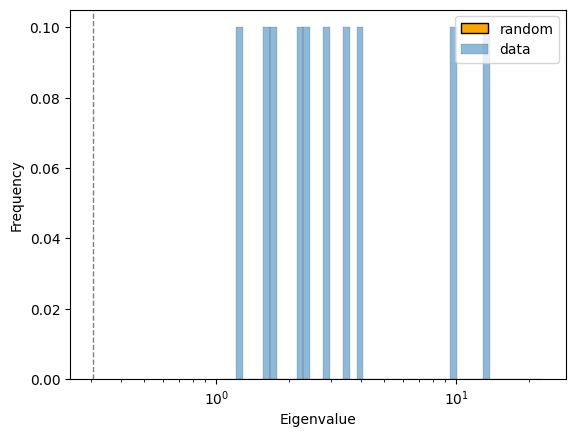

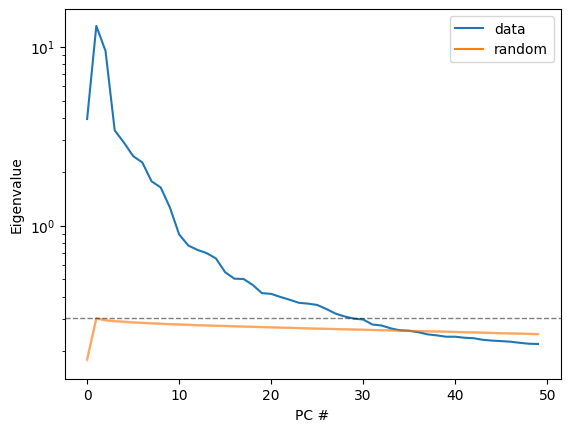

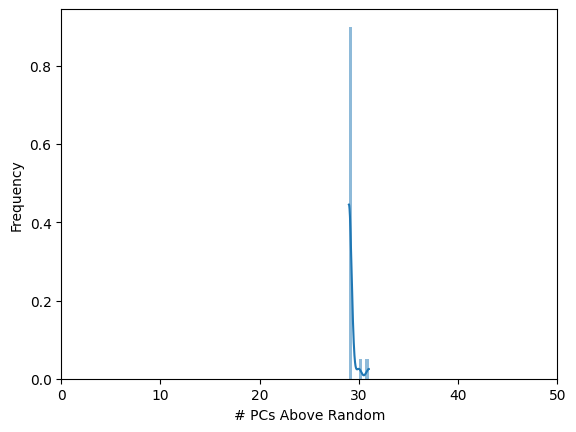


Counting the # of PCs with eigenvalues above random in >95% of trials
Eigenvalue Threshold = 0.3
# Significant PCs = 29


In [ ]:
# Determine # of significant PC dimensions
get_significant_pcs(adata, n_iter = 20, nPCs_test = 50, show_plots=True, zero_center=False)

In [ ]:
# Perform PCA with a specified number of dimensions
# n_sig_PCs should be 29
sc.pp.pca(adata, n_comps=adata.uns['n_sig_PCs'])

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=adata.uns['n_sig_PCs'], metric='euclidean')

/usr/local/lib/python3.12/dist-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [ ]:
# Generate embedding
sc.tl.umap(adata, n_components=2, spread=1)

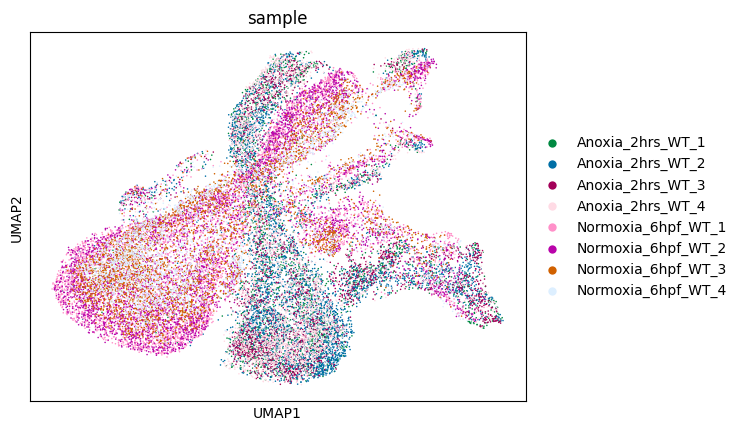

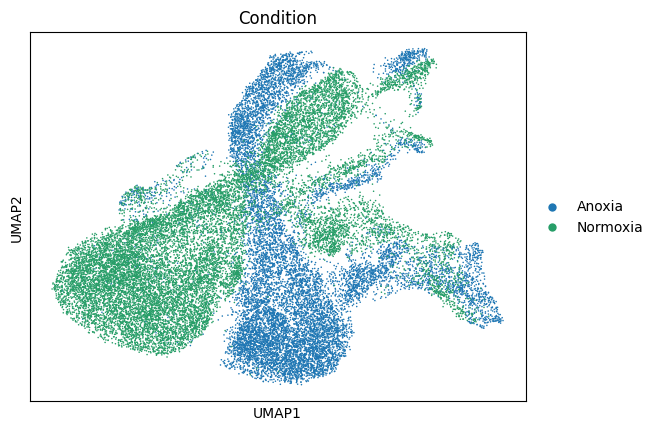

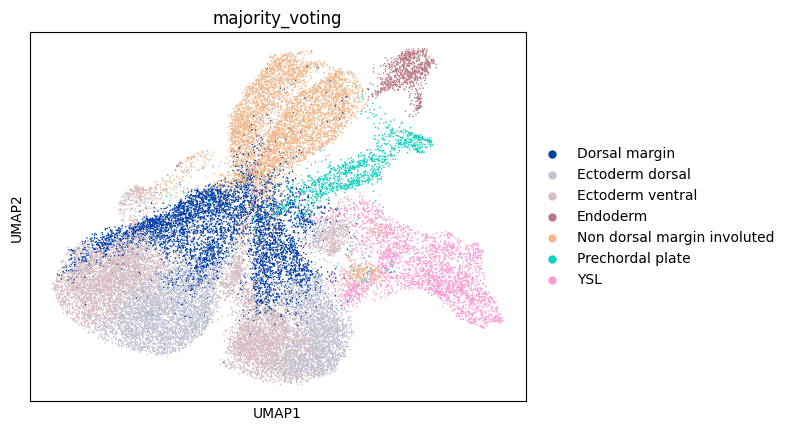

In [ ]:
sc.pl.umap(adata, color = 'sample', size = 5)
sc.pl.umap(adata, color = 'Condition', size = 5)
sc.pl.umap(adata, color = 'majority_voting', size = 5)

In [ ]:
# create a new obs column that is each cluster ('majority_voting') by each sample

adata_source.obs['cluster_sample'] = adata_source.obs['majority_voting'].astype(str) + "_" + adata_source.obs['sample'].astype(str)

In [ ]:
# define group to test

obs_key = "cluster_sample"  # defines groups to test

In [ ]:
# calculate euclidean distance in PC space using pertpy

distance = pt.tl.Distance("euclidean", obsm_key="X_pca")
df = distance.pairwise(adata, groupby=obs_key)

Output()

In [ ]:
df.to_csv('/HypoxiaClusterEucdistance_6hpfandHyp2_bysample.csv')

In [ ]:
df = pd.read_csv('/HypoxiaClusterEucdistance_6hpfandHyp2_bysample.csv')
df

,cluster_sample,Dorsal margin_Anoxia_2hrs_WT_1,Non dorsal margin involuted_Anoxia_2hrs_WT_1,Ectoderm dorsal_Anoxia_2hrs_WT_1,Ectoderm ventral_Anoxia_2hrs_WT_1,YSL_Anoxia_2hrs_WT_1,Prechordal plate_Anoxia_2hrs_WT_1,Endoderm_Anoxia_2hrs_WT_1,Non dorsal margin involuted_Anoxia_2hrs_WT_2,Ectoderm ventral_Anoxia_2hrs_WT_2,...,Non dorsal margin involuted_Normoxia_6hpf_WT_3,Dorsal margin_Normoxia_6hpf_WT_3,YSL_Normoxia_6hpf_WT_3,Ectoderm ventral_Normoxia_6hpf_WT_4,Dorsal margin_Normoxia_6hpf_WT_4,Non dorsal margin involuted_Normoxia_6hpf_WT_4,Prechordal plate_Normoxia_6hpf_WT_4,YSL_Normoxia_6hpf_WT_4,Ectoderm dorsal_Normoxia_6hpf_WT_4,Endoderm_Normoxia_6hpf_WT_4
0,Dorsal margin_Anoxia_2hrs_WT_1,0.000000,5.947438,4.702235,4.720729,12.105311,7.625648,9.441814,5.187253,4.854931,...,6.095176,2.977786,9.878240,5.465348,3.125745,5.997354,7.318167,12.697856,5.343174,8.978978
1,Non dorsal margin involuted_Anoxia_2hrs_WT_1,5.947438,0.000000,8.324256,8.279859,12.336291,6.855950,8.039050,2.115525,8.371183,...,3.367464,6.897996,9.978847,8.762967,7.098687,3.725516,7.136785,12.937113,8.780345,7.311558
2,Ectoderm dorsal_Anoxia_2hrs_WT_1,4.702235,8.324256,0.000000,2.782642,12.148472,8.785990,10.076802,7.772262,3.126704,...,8.494857,5.076666,10.333412,4.114512,5.111598,8.428813,8.399345,12.910342,2.972299,9.913383
3,Ectoderm ventral_Anoxia_2hrs_WT_1,4.720729,8.279859,2.782642,0.000000,12.290028,9.027557,9.849505,7.752686,1.397826,...,8.178952,4.651574,10.343001,2.565130,4.499666,8.034352,8.418803,12.877174,3.593553,9.487333
4,YSL_Anoxia_2hrs_WT_1,12.105311,12.336291,12.148472,12.290028,0.000000,12.668213,12.276473,12.177223,12.240602,...,12.766400,12.196767,5.852674,12.691569,12.489432,12.990993,12.975812,5.021219,12.615880,12.912072
5,Prechordal plate_Anoxia_2hrs_WT_1,7.625648,6.855950,8.785990,9.027557,12.668213,0.000000,8.734842,7.216053,9.096211,...,7.439550,8.238134,10.654145,9.521776,8.486566,7.591981,3.691995,13.289296,9.264571,8.565384
6,Endoderm_Anoxia_2hrs_WT_1,9.441814,8.039050,10.076802,9.849505,12.276473,8.734842,0.000000,8.551892,9.892015,...,8.288336,9.557674,10.464840,10.142715,9.712291,8.463982,8.727254,12.824059,10.337543,3.796474
7,Non dorsal margin involuted_Anoxia_2hrs_WT_2,5.187253,2.115525,7.772262,7.752686,12.177223,7.216053,8.551892,0.000000,7.692370,...,4.189771,6.357076,9.937531,8.342421,6.597826,4.538636,7.593638,12.911386,8.370085,8.190235
8,Ectoderm ventral_Anoxia_2hrs_WT_2,4.854931,8.371183,3.126704,1.397826,12.240602,9.096211,9.892015,7.692370,0.000000,...,8.353644,4.943696,10.334201,3.149020,4.870768,8.243511,8.600818,12.882555,4.186194,9.626822
9,YSL_Anoxia_2hrs_WT_2,11.521442,11.858274,11.549563,11.767946,2.213980,12.223140,12.001510,11.503455,11.593197,...,12.305253,11.644631,6.119377,12.178233,11.941876,12.533933,12.525075,5.849740,12.069114,12.628063


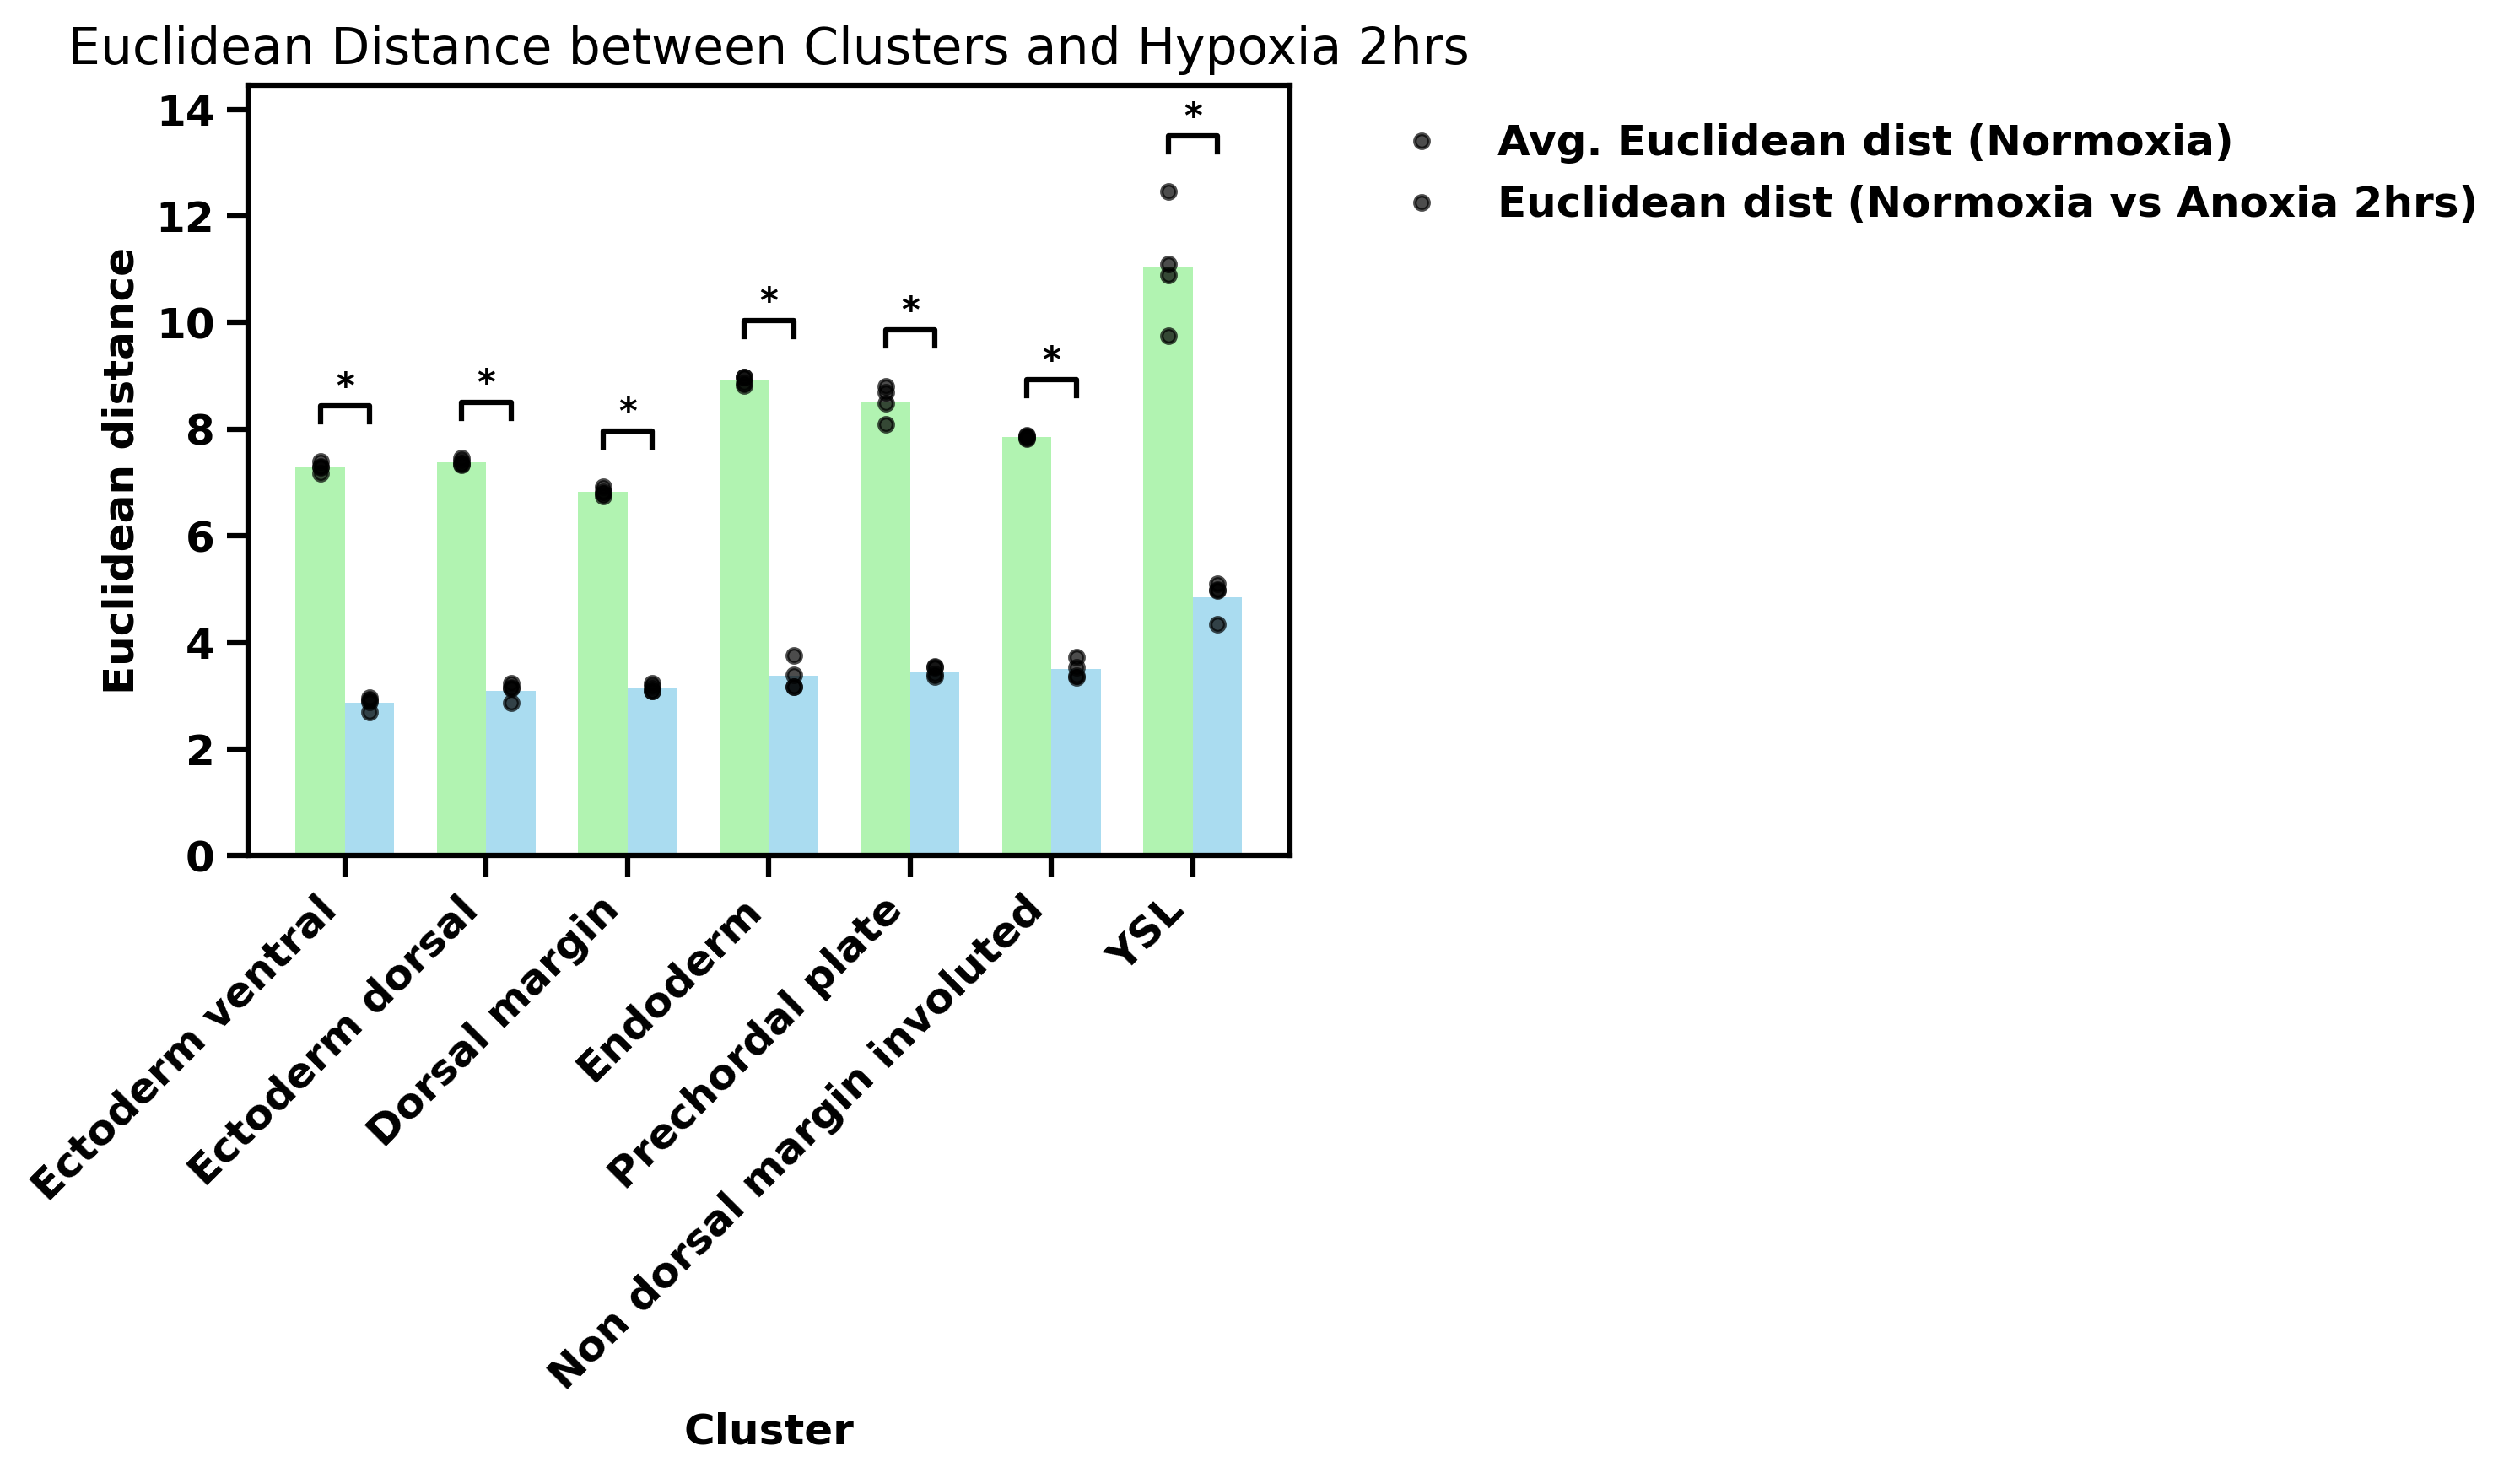

In [ ]:

# Load data
df = pd.read_csv('/HypoxiaClusterEucdistance_6hpfandHyp2_bysample.csv')
df.set_index('cluster_sample', inplace=True)

# Helpers to parse names
def parse_name(name):
    parts = name.split("_")
    if "Anoxia" in parts:
        cond_idx = parts.index("Anoxia")
    else:
        cond_idx = parts.index("Normoxia")
    cluster = " ".join(parts[:cond_idx])
    condition = "_".join(parts[cond_idx:-1])
    sample = parts[-1]
    return cluster, condition, sample

# Anoxia replicates: average distance to all Normoxia replicates
anoxia_records = []
norm_cols = [c for c in df.columns if "Normoxia" in c]

for r in df.index:
    if "Anoxia" in r:
        cluster, cond, rep = parse_name(r)
        # restrict to same cluster's Normoxia samples
        cluster_norm_cols = [c for c in norm_cols if parse_name(c)[0] == cluster]
        if cluster_norm_cols:
            vals = df.loc[r, cluster_norm_cols]
            avg_dist = vals.mean()
            anoxia_records.append({
                "Cluster": cluster,
                "ConditionType": "Anoxia_vs_Normoxia",
                "Distance": avg_dist,
                "Replicate": rep,
                "Condition": cond
            })

anoxia_df = pd.DataFrame(anoxia_records)


# Normoxia replicates: each sample avg distance to ALL other Normoxia samples
norm_records = []
norm_cols = [c for c in df.columns if "Normoxia" in c]

for r in df.index:
    if "Normoxia" in r:
        cluster, cond, rep = parse_name(r)

        # Get normoxia columns that are NOT in the same cluster
        other_norm_cols = [
            c for c in norm_cols
            if parse_name(c)[0] != cluster and c != r
        ]

        # Only proceed if there are valid columns to average
        if other_norm_cols:
            vals = df.loc[r, other_norm_cols]
            avg_dist = vals.mean()

            norm_records.append({
                "Cluster": cluster,
                "ConditionType": "Normoxia_vs_Normoxia",
                "Distance": avg_dist,
                "Replicate": rep,
                "Condition": cond
            })


norm_df = pd.DataFrame(norm_records)

# Merge
long_df = pd.concat([anoxia_df, norm_df])

# Filter clusters of interest
enough = ['Dorsal margin','Non dorsal margin involuted','Ectoderm ventral',
          'Ectoderm dorsal','YSL','Endoderm','Prechordal plate']
long_df = long_df.loc[long_df["Cluster"].isin(enough)]

# Order clusters by mean Anoxia distance
cluster_order = (
    long_df.query("ConditionType == 'Anoxia_vs_Normoxia'")
    .groupby("Cluster")["Distance"]
    .mean()
    .sort_values()
    .index
)

# Compute means for bar heights
bar_means = (
    long_df.groupby(["Cluster","ConditionType"])["Distance"]
    .mean()
    .reset_index()
)

# Plot
plt.rcParams.update({
    'font.size': 12, 'font.weight': 'bold',
    'axes.labelweight': 'bold', 'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.major.size': 6, 'ytick.major.size': 6, 'axes.linewidth': 1.5
})

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

x_positions = {cl:i for i,cl in enumerate(cluster_order)}
width = 0.35

colors = {"Normoxia_vs_Normoxia":"lightgreen",
          "Anoxia_vs_Normoxia":"skyblue"}

# Draw bars (cluster means)
for cond_type in ["Normoxia_vs_Normoxia","Anoxia_vs_Normoxia"]:
    offset = -width/2 if cond_type=="Normoxia_vs_Normoxia" else width/2
    for cl in cluster_order:
        mean_val = bar_means.query("Cluster == @cl and ConditionType == @cond_type")["Distance"]
        if not mean_val.empty:
            ax.bar(x_positions[cl]+offset, mean_val.values[0], width,
                   color=colors[cond_type], alpha=0.7, label=cond_type if cl==cluster_order[0] else "")

# Overlay replicate dots
for cond_type in ["Normoxia_vs_Normoxia","Anoxia_vs_Normoxia"]:
    offset = -width/2 if cond_type=="Normoxia_vs_Normoxia" else width/2
    sub = long_df[long_df["ConditionType"]==cond_type]
    for _, row in sub.iterrows():
        ax.plot(x_positions[row["Cluster"]] + offset,
                row["Distance"], 'o', color='k', markersize=4, alpha=0.7)

# Final formatting
ax.set_xticks(range(len(cluster_order)))
ax.set_xticklabels(cluster_order, rotation=45, ha="right")
ax.set_xlabel("Cluster")
ax.set_ylabel("Euclidean distance")
ax.set_title("Euclidean Distance between Clusters and Hypoxia 2hrs")
ax.legend(["Avg. Euclidean dist (Normoxia)", "Euclidean dist (Normoxia vs Anoxia 2hrs)"],
          loc="upper left", bbox_to_anchor=(1.05,1))


# Perform Mann-Whitney U test and annotate p-values
y_offset = 0.05  # Vertical spacing for annotation above the bars

for cl in cluster_order:
    sub = long_df[long_df["Cluster"] == cl]
    group1 = sub[sub["ConditionType"] == "Anoxia_vs_Normoxia"]["Distance"]
    group2 = sub[sub["ConditionType"] == "Normoxia_vs_Normoxia"]["Distance"]

    # Ensure both groups have values
    if not group1.empty and not group2.empty:
        stat, p = mannwhitneyu(group1, group2, alternative='two-sided')

        # Get max y for the current cluster's bars to position the annotation
        max_y = max(group1.max(), group2.max())

        # Format p-value (you can customize how it's displayed)
        if p < 0.001:
            p_text = '***'
        elif p < 0.01:
            p_text = '**'
        elif p < 0.05:
            p_text = '*'
        else:
            p_text = 'ns'

        # Draw a line between the two bars
        x1 = x_positions[cl] - width/2
        x2 = x_positions[cl] + width/2
        y = max_y + y_offset

        ax.plot([x1, x1, x2, x2], [y+0.7, y +1, y + 1, y+0.7], lw=1.5, c='k')
        ax.text((x1 + x2) / 2, y + 1, p_text, ha='center', va='bottom', fontsize=10, fontweight='bold')


# Automatically determine max y-value and raise the limit
y_max = long_df["Distance"].max()
ax.set_ylim(top=y_max + 2)


plt.tight_layout()

plt.savefig("/EuclideanDistanceHypoxiaBySampleWithStats.png", dpi=300, bbox_inches='tight')


plt.show()


# Reoxy Distance Measurement: By sample, with statistics

In [ ]:
adata = sc.read(data_path + 'h5ad/Preprocessed_Annotated.h5ad')

In [ ]:
#filter

OfInterst = ['Normoxia_6hpf_WT', 'Reoxy_2hrs_WT', 'Normoxia_8hpf_WT']
sliceindex = adata.obs['Group'].isin(OfInterst)
adata = adata[sliceindex].copy()

In [ ]:
enough = ['Dorsal margin',
 'Non dorsal margin involuted',
 'Ectoderm ventral',
 'Ectoderm dorsal',
 'YSL',
 'Endoderm',
 'Prechordal plate',
 'Tailbud spinal cord 8hpf',
 'Epidermis 8hpf',
 'Neural plate posterior',
 'Tailbud PSM',
 'Neural plate anterior']

In [ ]:
#filter


sliceindex = adata.obs['majority_voting'].isin(enough)
adata = adata[sliceindex].copy()

Performing PCA on data
Performing PCA on randomized data
Iteration 20 / 20

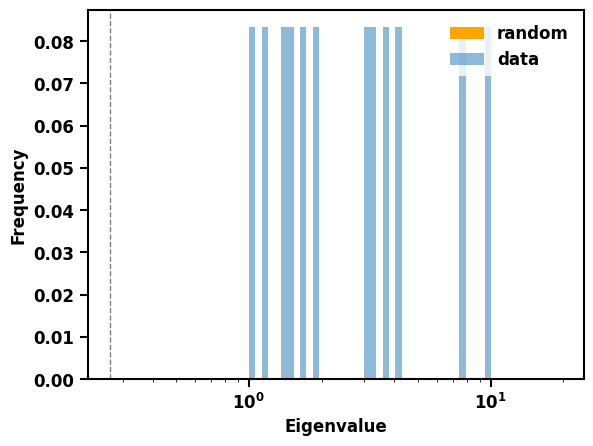

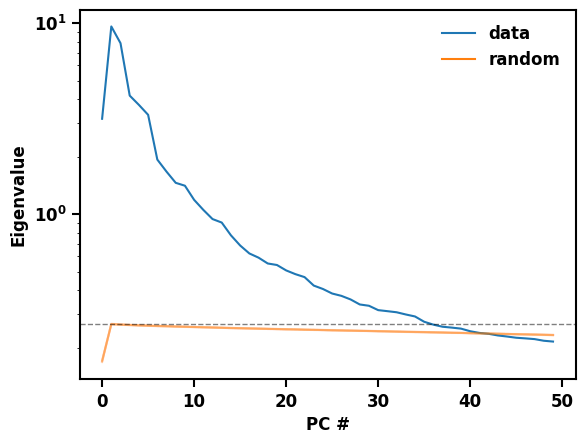

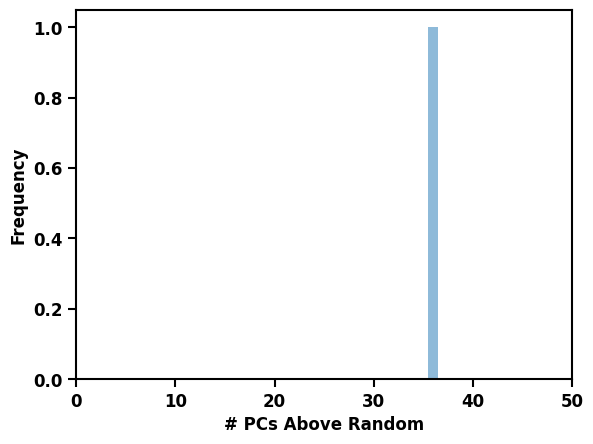


Counting the # of PCs with eigenvalues above random in >95% of trials
Eigenvalue Threshold = 0.27
# Significant PCs = 36


In [ ]:
# Determine # of significant PC dimensions
get_significant_pcs(adata, n_iter = 20, nPCs_test = 50, show_plots=True, zero_center=False)

In [ ]:
# Perform PCA with a specified number of dimensions, should be ~27
sc.pp.pca(adata, n_comps=adata.uns['n_sig_PCs'])

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=adata.uns['n_sig_PCs'], metric='euclidean')

In [ ]:
# Generate embedding
sc.tl.umap(adata, n_components=2, spread=1)

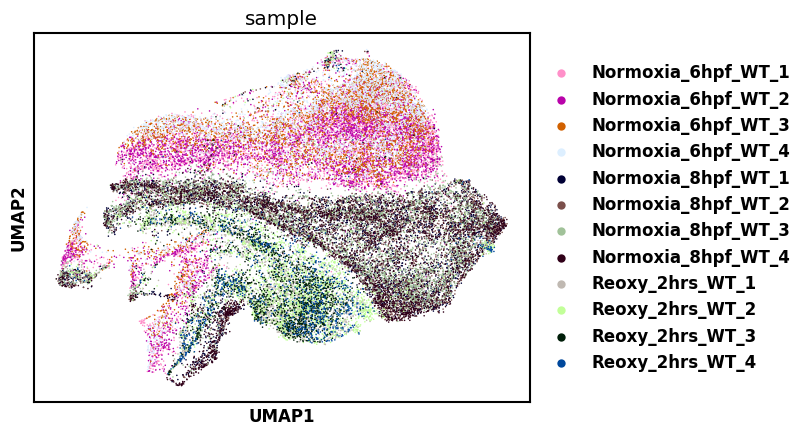

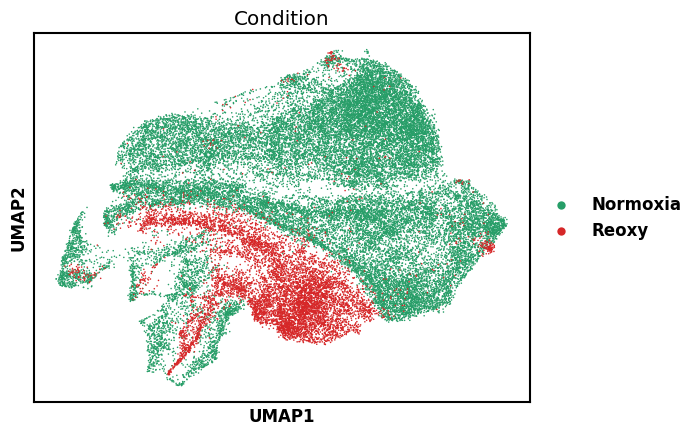

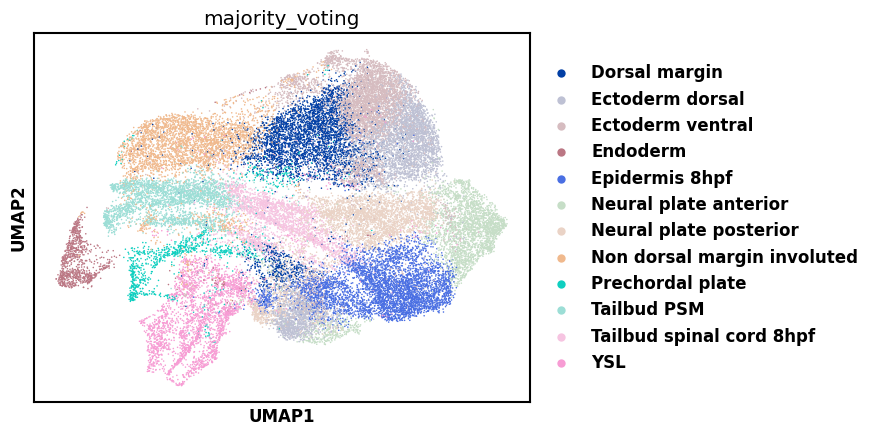

In [ ]:
sc.pl.umap(adata, color = 'sample', size = 5)
sc.pl.umap(adata, color = 'Condition', size = 5)
sc.pl.umap(adata, color = 'majority_voting', size = 5)

In [ ]:
# create a new obs column that is each cluster ('majority_voting') by each sample

adata_source.obs['cluster_sample'] = adata_source.obs['majority_voting'].astype(str) + "_" + adata_source.obs['sample'].astype(str)

In [ ]:
# define group to test

obs_key = "cluster_sample"  # defines groups to test

In [ ]:
distance = pt.tl.Distance("euclidean", obsm_key="X_pca")
df = distance.pairwise(adata, groupby=obs_key)

Output()

In [ ]:
df.to_csv('/ReoxyClusterEucdistance_6and8vsReoxy_bysample.csv')

In [ ]:
df = pd.read_csv('/ReoxyClusterEucdistance_6and8vsReoxy_bysample.csv')
df

,cluster_sample,Dorsal margin_Normoxia_6hpf_WT_1,Non dorsal margin involuted_Normoxia_6hpf_WT_1,Ectoderm ventral_Normoxia_6hpf_WT_1,Ectoderm dorsal_Normoxia_6hpf_WT_1,YSL_Normoxia_6hpf_WT_1,Endoderm_Normoxia_6hpf_WT_1,Prechordal plate_Normoxia_6hpf_WT_1,Epidermis 8hpf_Normoxia_6hpf_WT_1,Neural plate anterior_Normoxia_6hpf_WT_1,...,Epidermis 8hpf_Reoxy_2hrs_WT_4,Ectoderm ventral_Reoxy_2hrs_WT_4,Neural plate anterior_Reoxy_2hrs_WT_4,Ectoderm dorsal_Reoxy_2hrs_WT_4,Dorsal margin_Reoxy_2hrs_WT_4,Tailbud spinal cord 8hpf_Reoxy_2hrs_WT_4,Non dorsal margin involuted_Reoxy_2hrs_WT_4,Tailbud PSM_Reoxy_2hrs_WT_4,Prechordal plate_Reoxy_2hrs_WT_4,Endoderm_Reoxy_2hrs_WT_4
0,Dorsal margin_Normoxia_6hpf_WT_1,0.000000,5.925372,3.762725,4.076429,10.555951,8.455432,7.781404,4.571318,6.024403,...,5.966187,4.593581,7.070455,5.491061,4.089640,4.492416,6.092289,8.078628,7.293434,8.933254
1,Non dorsal margin involuted_Normoxia_6hpf_WT_1,5.925372,0.000000,7.797700,7.983163,11.177536,7.481589,7.268848,8.342046,9.185613,...,9.242603,8.250944,9.623664,8.815016,7.601349,6.995502,4.348716,4.644551,7.377352,9.080695
2,Ectoderm ventral_Normoxia_6hpf_WT_1,3.762725,7.797700,0.000000,3.164463,10.900823,8.984754,8.713820,2.605101,5.185878,...,4.545944,3.580996,6.391945,4.682942,5.976218,6.685185,8.062244,9.682303,8.531959,9.373541
3,Ectoderm dorsal_Normoxia_6hpf_WT_1,4.076429,7.983163,3.164463,0.000000,10.848149,9.350590,8.494259,4.746172,3.273168,...,5.700405,4.035272,5.358222,3.464320,5.602430,6.676557,8.082131,9.702050,8.207117,9.556917
4,YSL_Normoxia_6hpf_WT_1,10.555951,11.177536,10.900823,10.848149,0.000000,11.168692,11.483298,11.021892,11.392199,...,11.566963,11.765784,11.822232,11.596004,11.059180,11.528238,11.567464,12.036140,10.999338,11.179648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Tailbud spinal cord 8hpf_Reoxy_2hrs_WT_4,4.492416,6.995502,6.685185,6.676557,11.528238,9.852537,8.836083,6.782095,7.489729,...,6.194519,5.600795,7.104707,5.889257,2.442939,0.000000,4.428104,6.931890,6.459206,8.606372
133,Non dorsal margin involuted_Reoxy_2hrs_WT_4,6.092289,4.348716,8.062244,8.082131,11.567464,9.004747,8.079281,8.402158,8.852286,...,8.225884,7.305265,8.609024,7.592989,5.542368,4.428104,0.000000,3.011639,6.066827,8.377924
134,Tailbud PSM_Reoxy_2hrs_WT_4,8.078628,4.644551,9.682303,9.702050,12.036140,9.464057,8.902436,9.878040,10.264985,...,9.784323,9.197883,10.022767,9.315178,7.752193,6.931890,3.011639,0.000000,7.186382,8.819979
135,Prechordal plate_Reoxy_2hrs_WT_4,7.293434,7.377352,8.531959,8.207117,10.999338,8.987926,4.394068,8.711083,8.461209,...,8.229787,7.968117,7.952159,7.799773,6.387744,6.459206,6.066827,7.186382,0.000000,8.022143


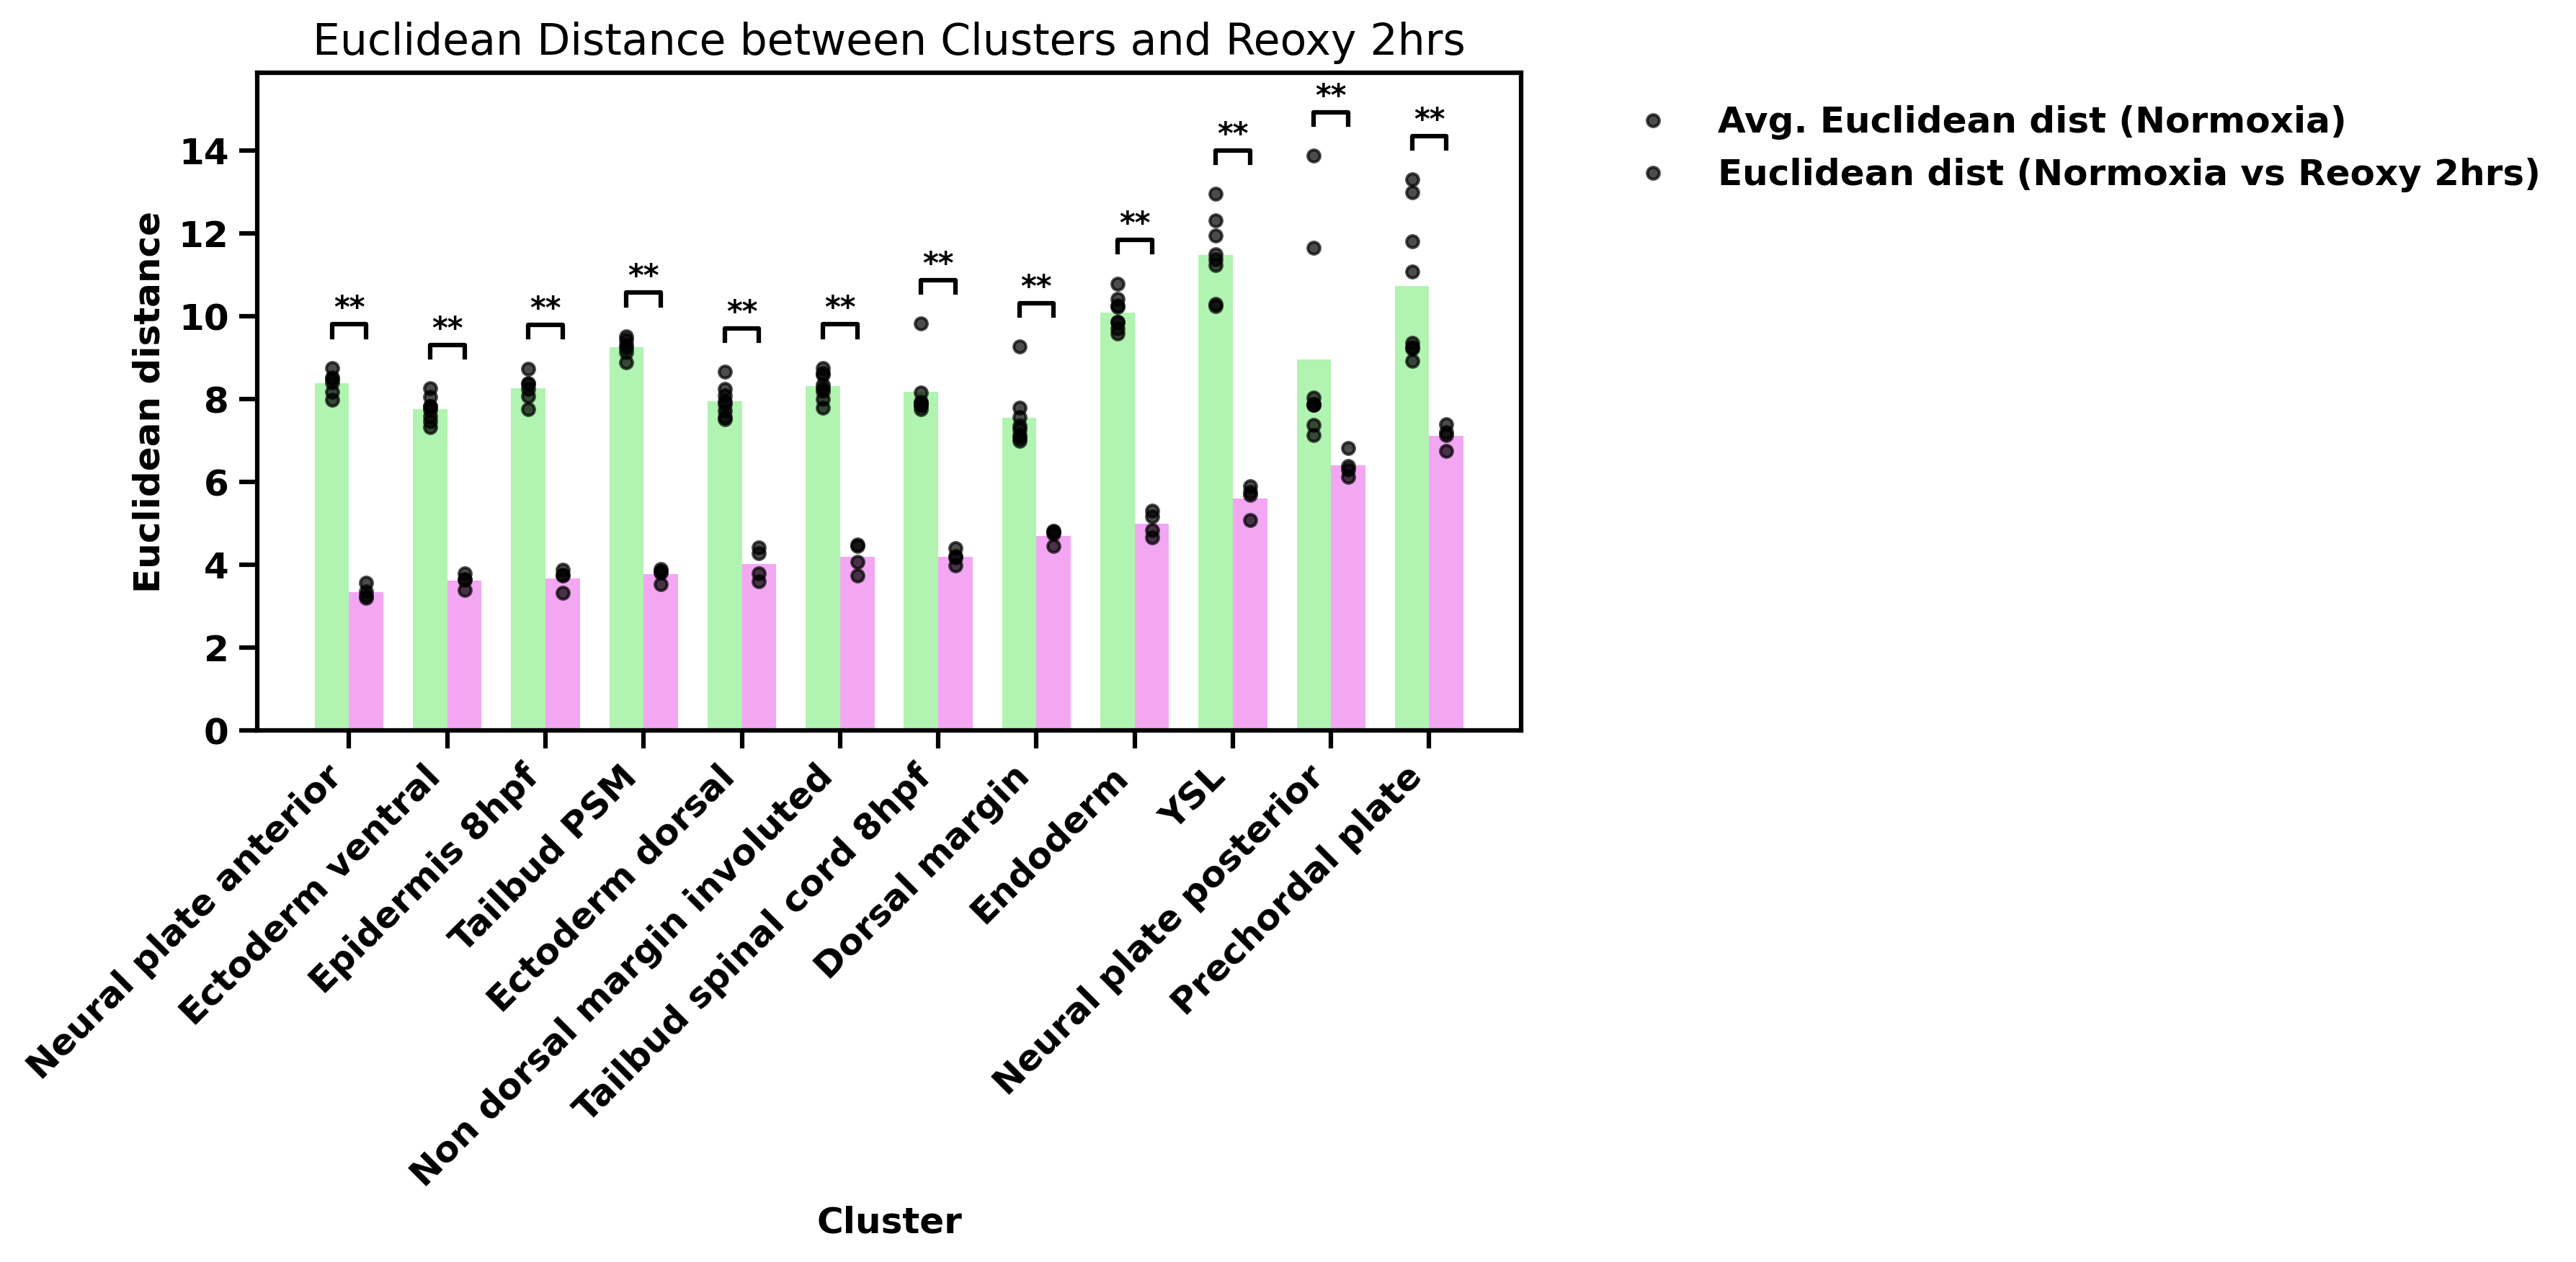

In [ ]:

# Load data
df = pd.read_csv('/ReoxyClusterEucdistance_6and8vsReoxy_bysample.csv')
df.set_index('cluster_sample', inplace=True)

# Helpers to parse names
def parse_name(name):
    parts = name.split("_")
    if "Reoxy" in parts:
        cond_idx = parts.index("Reoxy")
    else:
        cond_idx = parts.index("Normoxia")
    cluster = " ".join(parts[:cond_idx])
    condition = "_".join(parts[cond_idx:-1])
    sample = parts[-1]
    return cluster, condition, sample

# Reoxy replicates: average distance to all Normoxia replicates
Reoxy_records = []
norm_cols = [c for c in df.columns if "Normoxia" in c]

for r in df.index:
    if "Reoxy" in r:
        cluster, cond, rep = parse_name(r)
        # restrict to same cluster's Normoxia samples
        cluster_norm_cols = [c for c in norm_cols if parse_name(c)[0] == cluster]
        if cluster_norm_cols:
            vals = df.loc[r, cluster_norm_cols]
            avg_dist = vals.mean()
            Reoxy_records.append({
                "Cluster": cluster,
                "ConditionType": "Reoxy_vs_Normoxia",
                "Distance": avg_dist,
                "Replicate": rep,
                "Condition": cond
            })

Reoxy_df = pd.DataFrame(Reoxy_records)


# Normoxia replicates: each sample avg distance to ALL other Normoxia samples
norm_records = []
norm_cols = [c for c in df.columns if "Normoxia" in c]

for r in df.index:
    if "Normoxia" in r:
        cluster, cond, rep = parse_name(r)

        # Get normoxia columns that are NOT in the same cluster
        other_norm_cols = [
            c for c in norm_cols
            if parse_name(c)[0] != cluster and c != r
        ]

        # Only proceed if there are valid columns to average
        if other_norm_cols:
            vals = df.loc[r, other_norm_cols]
            avg_dist = vals.mean()

            norm_records.append({
                "Cluster": cluster,
                "ConditionType": "Normoxia_vs_Normoxia",
                "Distance": avg_dist,
                "Replicate": rep,
                "Condition": cond
            })


norm_df = pd.DataFrame(norm_records)

# Merge
long_df = pd.concat([Reoxy_df, norm_df])

# Filter clusters of interest
enough = ['Dorsal margin',
 'Non dorsal margin involuted',
 'Ectoderm ventral',
 'Ectoderm dorsal',
 'YSL',
 'Endoderm',
 'Prechordal plate',
 'Tailbud spinal cord 8hpf',
 'Epidermis 8hpf',
 'Neural plate posterior',
 'Tailbud PSM',
 'Neural plate anterior']
long_df = long_df.loc[long_df["Cluster"].isin(enough)]

# Order clusters by mean Reoxy distance
cluster_order = (
    long_df.query("ConditionType == 'Reoxy_vs_Normoxia'")
    .groupby("Cluster")["Distance"]
    .mean()
    .sort_values()
    .index
)

# Compute means for bar heights
bar_means = (
    long_df.groupby(["Cluster","ConditionType"])["Distance"]
    .mean()
    .reset_index()
)

# Plot
plt.rcParams.update({
    'font.size': 12, 'font.weight': 'bold',
    'axes.labelweight': 'bold', 'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'xtick.major.size': 6, 'ytick.major.size': 6, 'axes.linewidth': 1.5
})

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

x_positions = {cl:i for i,cl in enumerate(cluster_order)}
width = 0.35

colors = {"Normoxia_vs_Normoxia":"lightgreen",
          "Reoxy_vs_Normoxia":"violet"}

# Draw bars (cluster means)
for cond_type in ["Normoxia_vs_Normoxia","Reoxy_vs_Normoxia"]:
    offset = -width/2 if cond_type=="Normoxia_vs_Normoxia" else width/2
    for cl in cluster_order:
        mean_val = bar_means.query("Cluster == @cl and ConditionType == @cond_type")["Distance"]
        if not mean_val.empty:
            ax.bar(x_positions[cl]+offset, mean_val.values[0], width,
                   color=colors[cond_type], alpha=0.7, label=cond_type if cl==cluster_order[0] else "")

# Overlay replicate dots
for cond_type in ["Normoxia_vs_Normoxia","Reoxy_vs_Normoxia"]:
    offset = -width/2 if cond_type=="Normoxia_vs_Normoxia" else width/2
    sub = long_df[long_df["ConditionType"]==cond_type]
    for _, row in sub.iterrows():
        ax.plot(x_positions[row["Cluster"]] + offset,
                row["Distance"], 'o', color='k', markersize=4, alpha=0.7)

# Final formatting
ax.set_xticks(range(len(cluster_order)))
ax.set_xticklabels(cluster_order, rotation=45, ha="right")
ax.set_xlabel("Cluster")
ax.set_ylabel("Euclidean distance")
ax.set_title("Euclidean Distance between Clusters and Reoxy 2hrs")
ax.legend(["Avg. Euclidean dist (Normoxia)", "Euclidean dist (Normoxia vs Reoxy 2hrs)"],
          loc="upper left", bbox_to_anchor=(1.05,1))

# Perform Mann-Whitney U test and annotate p-values
y_offset = 0.05  # Vertical spacing for annotation above the bars

for cl in cluster_order:
    sub = long_df[long_df["Cluster"] == cl]
    group1 = sub[sub["ConditionType"] == "Reoxy_vs_Normoxia"]["Distance"]
    group2 = sub[sub["ConditionType"] == "Normoxia_vs_Normoxia"]["Distance"]

    # Ensure both groups have values
    if not group1.empty and not group2.empty:
        stat, p = mannwhitneyu(group1, group2, alternative='two-sided')

        # Get max y for the current cluster's bars to position the annotation
        max_y = max(group1.max(), group2.max())

        # Format p-value (you can customize how it's displayed)
        if p < 0.001:
            p_text = '***'
        elif p < 0.01:
            p_text = '**'
        elif p < 0.05:
            p_text = '*'
        else:
            p_text = 'ns'

        # Draw a line between the two bars
        x1 = x_positions[cl] - width/2
        x2 = x_positions[cl] + width/2
        y = max_y + y_offset

        ax.plot([x1, x1, x2, x2], [y+0.7, y +1, y + 1, y+0.7], lw=1.5, c='k')
        ax.text((x1 + x2) / 2, y + 1, p_text, ha='center', va='bottom', fontsize=10, fontweight='bold')


# Automatically determine max y-value and raise the limit
y_max = long_df["Distance"].max()
ax.set_ylim(top=y_max + 2)


plt.tight_layout()

plt.savefig("/EuclideanDistanceReoxyBySampleWithStats.png", dpi=300, bbox_inches='tight')


plt.show()


# Distance Heatmaps

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from seaborn import clustermap

In [ ]:
df = pd.read_csv('/HypoxiaReoxyClusterEucdistances.csv')

# this is another csv, generated similarly to as above but the subset was with normoxia 6hpf, normoxia 8hpf, hypoxia 2hrs, and reoxy 2hrs. The distance measurment was also not done by sample, but by cluster_condition.

In [ ]:
df

,cluster_condition,Dorsal margin_Anoxia,Non dorsal margin involuted_Anoxia,Ectoderm dorsal_Anoxia,Ectoderm ventral_Anoxia,YSL_Anoxia,Prechordal plate_Anoxia,Endoderm_Anoxia,Forerunner cells_Anoxia,EVL_Anoxia,...,Neural plate anterior_Reoxy,Endoderm_Reoxy,Notochord_Reoxy,YSL_Reoxy,Non dorsal margin involuted_Reoxy,Ectoderm ventral_Reoxy,Prechordal plate_Reoxy,EVL_Reoxy,Germline_Reoxy,Forerunner cells_Reoxy
0,Dorsal margin_Anoxia,0.000000,5.643013,4.623663,4.606743,11.627293,7.315193,9.078016,12.840272,24.559259,...,7.138259,9.370658,10.561777,10.183602,5.397335,4.772296,6.817089,24.315405,6.096559,14.771333
1,Non dorsal margin involuted_Anoxia,5.643013,0.000000,8.081059,8.065588,11.906848,6.766595,7.880210,13.269587,25.006083,...,9.429584,9.390110,10.090708,10.609229,3.670083,8.167785,7.333888,24.847418,8.363125,15.235207
2,Ectoderm dorsal_Anoxia,4.623663,8.081059,0.000000,2.823340,11.608727,8.411143,9.794699,13.256630,24.462688,...,4.989984,9.594026,11.279797,10.138934,7.580222,3.575584,7.862723,24.117281,6.192886,15.042981
3,Ectoderm ventral_Anoxia,4.606743,8.065588,2.823340,0.000000,11.765150,8.648162,9.571338,13.166964,24.264791,...,6.225161,9.716340,11.582643,10.497990,7.631402,2.853422,8.314253,23.830343,5.476171,15.066897
4,YSL_Anoxia,11.627293,11.906848,11.608727,11.765150,0.000000,12.127648,12.087522,13.539446,21.830721,...,12.060907,11.583153,13.539408,6.139160,11.863249,11.873672,11.308506,21.777967,10.956888,15.281883
5,Prechordal plate_Anoxia,7.315193,6.766595,8.411143,8.648162,12.127648,0.000000,8.423883,13.315269,25.002213,...,9.295347,9.586939,6.765195,10.902946,7.210493,8.704510,4.693834,24.852509,8.705157,15.213449
6,Endoderm_Anoxia,9.078016,7.880210,9.794699,9.571338,12.087522,8.423883,0.000000,12.706711,25.403824,...,10.679280,5.558440,11.506822,11.267112,8.475438,9.716955,9.189419,25.139591,9.961468,14.746548
7,Forerunner cells_Anoxia,12.840272,13.269587,13.256630,13.166964,13.539446,13.315269,12.706711,0.000000,23.708334,...,13.710126,12.915560,14.594482,13.160555,13.377655,13.208880,12.748745,23.651978,12.632492,4.265762
8,EVL_Anoxia,24.559259,25.006083,24.462688,24.264791,21.830721,25.002213,25.403824,23.708334,0.000000,...,24.724993,25.029282,25.643608,22.596512,25.031567,23.958923,24.402567,5.631399,22.961277,25.175434
9,Neural plate posterior_Anoxia,4.830017,7.869561,5.139347,5.402243,10.624152,8.539281,9.988410,12.001540,21.142994,...,6.973745,9.819794,11.223044,9.351580,7.416827,4.903411,7.666050,21.247425,6.638406,14.032269


In [ ]:
df = df.replace('Anoxia', 'Hypoxia', regex=True)
df.columns = df.columns.str.replace('Anoxia', 'Hypoxia')

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


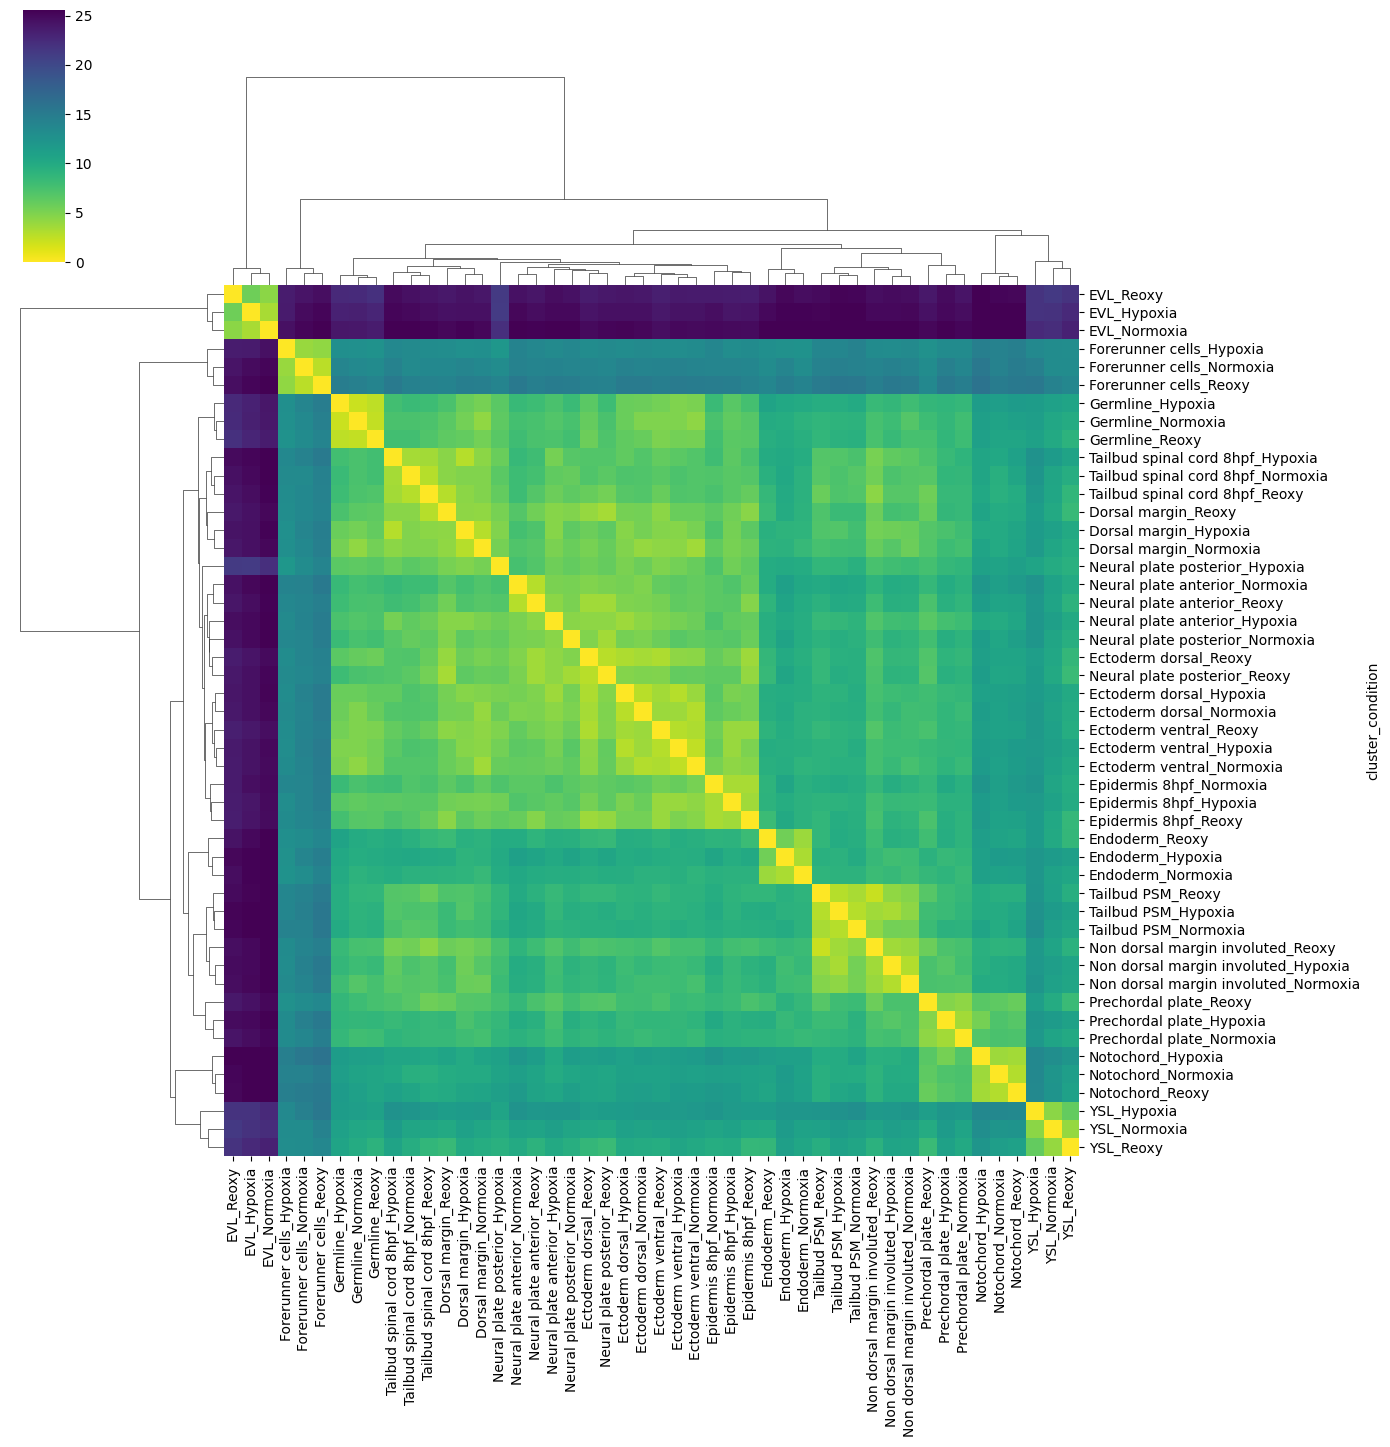

In [ ]:

# Set the first column as index (since it’s labels, not numeric data)
df_numeric = df.set_index('cluster_condition')

# Plot clustermap
g = sns.clustermap(df_numeric, robust=True, figsize=(14, 14), cmap = 'viridis_r', cbar_pos = (0.02, 0.85, 0.03, 0.18))


#plt.savefig('//HypoxiaReoxyAbundantclustermap_withdendro.png', dpi=600, bbox_inches='tight')


plt.show()

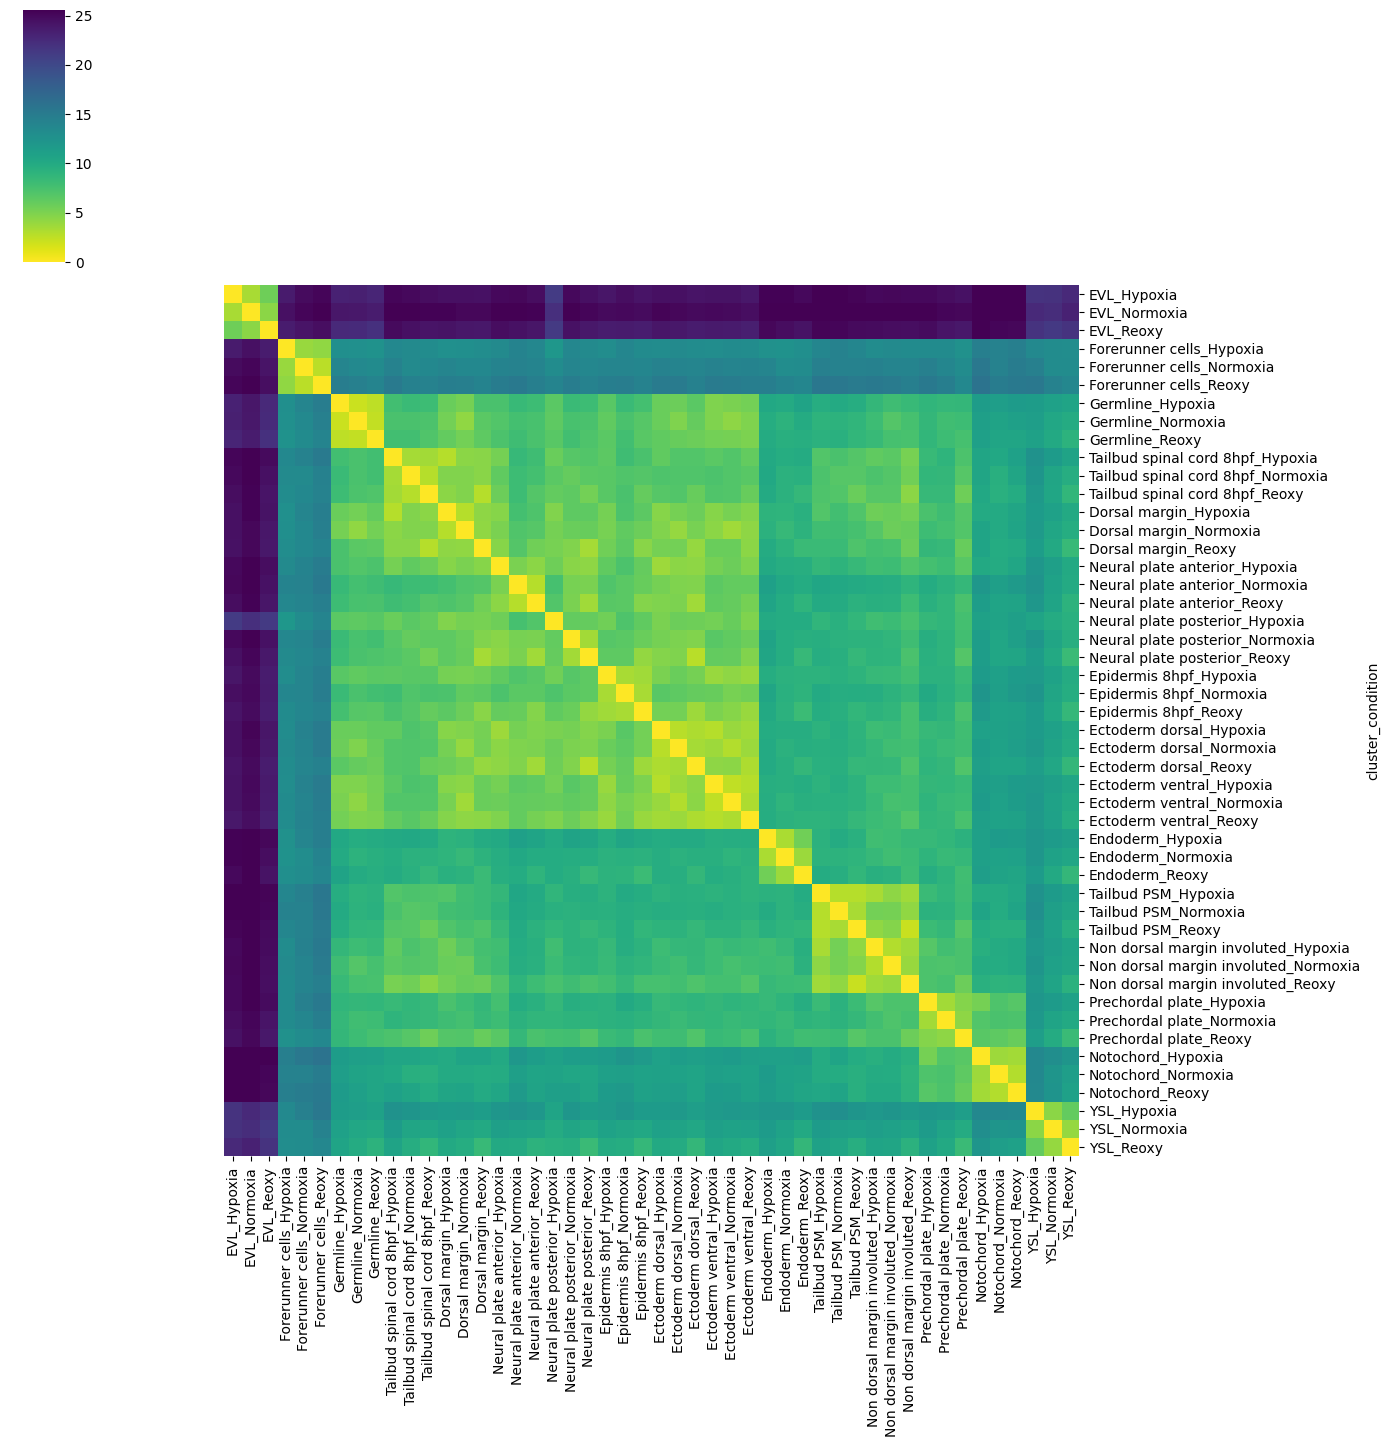

In [ ]:
# Set the first column as index
df_numeric = df.set_index('cluster_condition')

# Define your desired order
cell_types = ['EVL',
'Forerunner cells',
'Germline',
 'Tailbud spinal cord 8hpf',
'Dorsal margin',
 'Neural plate anterior',
 'Neural plate posterior',
 'Epidermis 8hpf',
 'Ectoderm dorsal',
 'Ectoderm ventral',
 'Endoderm',
 'Tailbud PSM',
 'Non dorsal margin involuted',
 'Prechordal plate',
'Notochord', 'YSL'
]
conditions = ['Hypoxia', 'Normoxia', 'Reoxy']

# Create the ordered row list
ordered_rows = []
for cell_type in cell_types:
    for condition in conditions:
        # Find rows that match this cell type and condition
        row_name = f"{cell_type}_{condition}"
        if row_name in df_numeric.index:
            ordered_rows.append(row_name)

# Create the ordered column list (same logic)
ordered_cols = []
for cell_type in cell_types:
    for condition in conditions:
        # Find columns that match this cell type and condition
        col_name = f"{cell_type}_{condition}"
        if col_name in df_numeric.columns:
            ordered_cols.append(col_name)

# Reorder both rows and columns
df_numeric = df_numeric.loc[ordered_rows, ordered_cols]

# Plot clustermap without dendrograms
g = sns.clustermap(df_numeric,
                   robust=True,
                   figsize=(14, 14),
                   cmap='viridis_r',
                   cbar_pos=(0.02, 0.85, 0.03, 0.18),
                   row_cluster=False,
                   col_cluster=False)

plt.savefig('/HypoxiaReoxyAbundantclustermap.png', dpi=600, bbox_inches='tight')

plt.show()